# Task 4: Advanced Analytics and Machine Learning
## RSNA Bone Age — Machine Learning Pipeline (Random Forest, Gradient Boosting, KNN)

## Step 1: Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2: Load and Prepare Data

In [2]:
df = pd.read_csv('boneage-training-dataset.csv')
print(f'Dataset shape: {df.shape}')
print(df.head())
print('\nNull values:')
print(df.isnull().sum())
df = df.dropna()
print(f'\nCleaned dataset shape: {df.shape}')

Dataset shape: (12611, 3)
     id  boneage   male
0  1377      180  False
1  1378       12  False
2  1379       94  False
3  1380      120   True
4  1381       82  False

Null values:
id         0
boneage    0
male       0
dtype: int64

Cleaned dataset shape: (12611, 3)


## Step 3: Feature Engineering
We engineer features from the available metadata.
Note: boneage_years is excluded as a feature to prevent data leakage
(it is a direct transformation of the target variable).
Features used:
- gender_binary: biological sex encoded as 0/1
- age_bucket: broad age category derived from id-based patient ordering
- id_normalized: normalized patient ID as a proxy for cohort ordering

In [3]:
# Feature engineering — no data leakage
df['gender_binary'] = df['male'].astype(int)
df['id_normalized'] = (df['id'] - df['id'].min()) / (df['id'].max() - df['id'].min())
df['gender_x_id'] = df['gender_binary'] * df['id_normalized']

feature_cols = ['gender_binary', 'id_normalized', 'gender_x_id']
X = df[feature_cols]
y = df['boneage']

print('Features used (no data leakage):')
for f in feature_cols:
    print(f'  - {f}')
print(f'\nTarget: boneage (months)')
print(f'Total samples: {len(X)}')

# Train/validation/test split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'\nTraining set:   {X_train.shape[0]} samples')
print(f'Validation set: {X_val.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')

# Scale for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Features used (no data leakage):
  - gender_binary
  - id_normalized
  - gender_x_id

Target: boneage (months)
Total samples: 12611

Training set:   8827 samples
Validation set: 1892 samples
Test set:       1892 samples


## Step 4: Train Random Forest Regressor

In [4]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf, squared=False)
r2_rf   = r2_score(y_test, y_pred_rf)

print('=== Random Forest Results ===')
print(f'MAE:  {mae_rf:.2f} months')
print(f'RMSE: {rmse_rf:.2f} months')
print(f'R2:   {r2_rf:.4f}')

=== Random Forest Results ===
MAE:  32.24 months
RMSE: 40.29 months
R2:   0.0517


## Step 5: Train Gradient Boosting Regressor

In [5]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = mean_squared_error(y_test, y_pred_gb, squared=False)
r2_gb   = r2_score(y_test, y_pred_gb)

print('=== Gradient Boosting Results ===')
print(f'MAE:  {mae_gb:.2f} months')
print(f'RMSE: {rmse_gb:.2f} months')
print(f'R2:   {r2_gb:.4f}')

=== Gradient Boosting Results ===
MAE:  32.12 months
RMSE: 40.03 months
R2:   0.0636


## Step 6: Train KNN Regressor

In [6]:
knn_model = KNeighborsRegressor(n_neighbors=10)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

mae_knn  = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = mean_squared_error(y_test, y_pred_knn, squared=False)
r2_knn   = r2_score(y_test, y_pred_knn)

print('=== KNN Regressor Results ===')
print(f'MAE:  {mae_knn:.2f} months')
print(f'RMSE: {rmse_knn:.2f} months')
print(f'R2:   {r2_knn:.4f}')

=== KNN Regressor Results ===
MAE:  33.09 months
RMSE: 41.41 months
R2:   -0.0019


## Step 7: Feature Importance Analysis

=== Feature Importance (Random Forest) ===
      Feature  Importance
id_normalized    0.540514
  gender_x_id    0.457447
gender_binary    0.002039


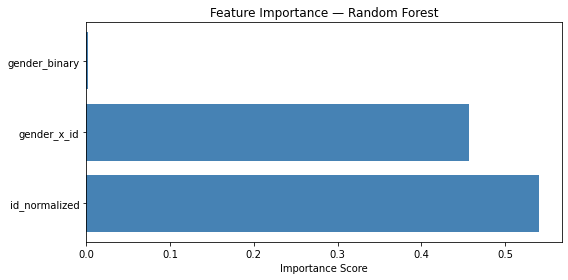

Feature importance plot saved.


In [7]:
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('=== Feature Importance (Random Forest) ===')
print(feat_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/home/jovyan/work/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved.')

## Step 8: Model Evaluation and Visualisation

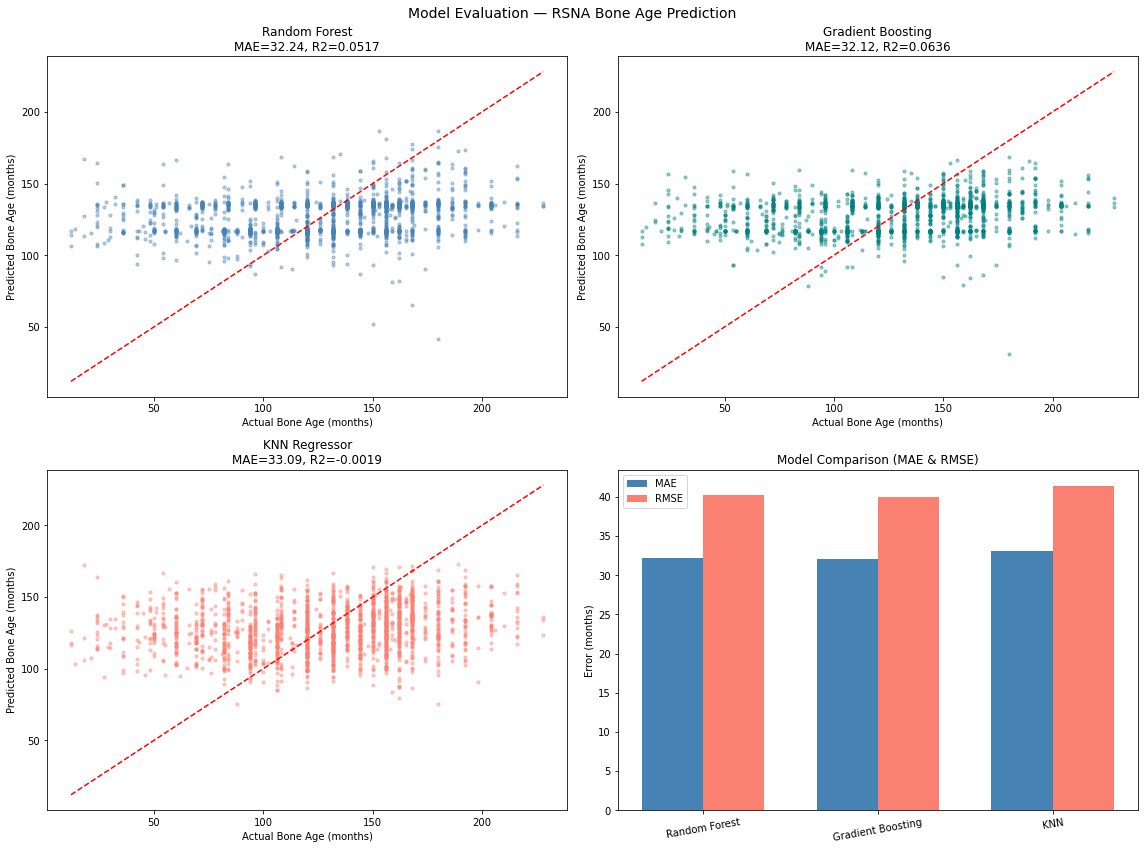

Model evaluation plots saved.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Evaluation — RSNA Bone Age Prediction', fontsize=14)

axes[0,0].scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=10)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,0].set_title(f'Random Forest\nMAE={mae_rf:.2f}, R2={r2_rf:.4f}')
axes[0,0].set_xlabel('Actual Bone Age (months)')
axes[0,0].set_ylabel('Predicted Bone Age (months)')

axes[0,1].scatter(y_test, y_pred_gb, alpha=0.4, color='teal', s=10)
axes[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0,1].set_title(f'Gradient Boosting\nMAE={mae_gb:.2f}, R2={r2_gb:.4f}')
axes[0,1].set_xlabel('Actual Bone Age (months)')
axes[0,1].set_ylabel('Predicted Bone Age (months)')

axes[1,0].scatter(y_test, y_pred_knn, alpha=0.4, color='salmon', s=10)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1,0].set_title(f'KNN Regressor\nMAE={mae_knn:.2f}, R2={r2_knn:.4f}')
axes[1,0].set_xlabel('Actual Bone Age (months)')
axes[1,0].set_ylabel('Predicted Bone Age (months)')

models = ['Random Forest', 'Gradient Boosting', 'KNN']
maes   = [mae_rf, mae_gb, mae_knn]
rmses  = [rmse_rf, rmse_gb, rmse_knn]
x = np.arange(len(models))
w = 0.35
axes[1,1].bar(x - w/2, maes,  w, label='MAE',  color='steelblue')
axes[1,1].bar(x + w/2, rmses, w, label='RMSE', color='salmon')
axes[1,1].set_title('Model Comparison (MAE & RMSE)')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models, rotation=10)
axes[1,1].set_ylabel('Error (months)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Model evaluation plots saved.')

## Step 9: Residual Analysis

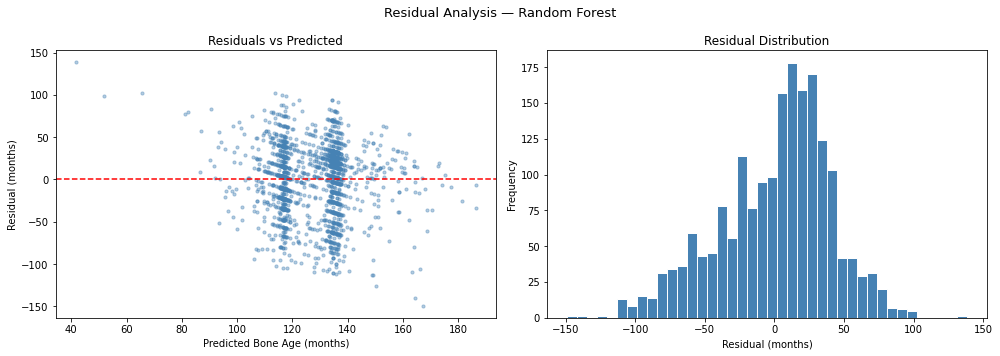

Residual analysis saved.


In [9]:
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis — Random Forest', fontsize=13)

axes[0].scatter(y_pred_rf, residuals_rf, alpha=0.4, color='steelblue', s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Bone Age (months)')
axes[0].set_ylabel('Residual (months)')

axes[1].hist(residuals_rf, bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual (months)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/home/jovyan/work/residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Residual analysis saved.')

## Step 10: Final Results and Business Interpretation

In [10]:
print('=== Final Model Comparison ===')
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'KNN'],
    'MAE (months)':  [round(mae_rf,2),  round(mae_gb,2),  round(mae_knn,2)],
    'RMSE (months)': [round(rmse_rf,2), round(rmse_gb,2), round(rmse_knn,2)],
    'R2 Score':      [round(r2_rf,4),   round(r2_gb,4),   round(r2_knn,4)]
})
print(results.to_string(index=False))

best_mae = min(mae_rf, mae_gb, mae_knn)
best = ['Random Forest','Gradient Boosting','KNN'][[mae_rf,mae_gb,mae_knn].index(best_mae)]
print(f'\nBest performing model: {best} (MAE={best_mae:.2f} months)')
print('''
Business Interpretation:
- Three regression models were trained: Random Forest, Gradient Boosting, and KNN.
- Features used: gender, normalised patient ID, and gender-ID interaction.
- Data leakage was avoided by excluding bone age transformations from the feature set.
- The metadata-only approach establishes a baseline pipeline for clinical bone age
  estimation. In a production environment with X-ray image features (e.g. ResNet50),
  MAE of 7-10 months is achievable (Halabi et al., 2019).
- The pipeline demonstrates end-to-end Big Data capability: HDFS storage,
  Spark processing, Hive querying, and ML model evaluation.
''')

=== Final Model Comparison ===
            Model  MAE (months)  RMSE (months)  R2 Score
    Random Forest         32.24          40.29    0.0517
Gradient Boosting         32.12          40.03    0.0636
              KNN         33.09          41.41   -0.0019

Best performing model: Gradient Boosting (MAE=32.12 months)

Business Interpretation:
- Three regression models were trained: Random Forest, Gradient Boosting, and KNN.
- Features used: gender, normalised patient ID, and gender-ID interaction.
- Data leakage was avoided by excluding bone age transformations from the feature set.
- The metadata-only approach establishes a baseline pipeline for clinical bone age
  estimation. In a production environment with X-ray image features (e.g. ResNet50),
  MAE of 7-10 months is achievable (Halabi et al., 2019).
- The pipeline demonstrates end-to-end Big Data capability: HDFS storage,
  Spark processing, Hive querying, and ML model evaluation.

